<a href="https://colab.research.google.com/github/eric56427/er1c/blob/main/Copy_of_Project2PartB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== R1: Testing with Figure 1 Graph ===
Paths from source to sink:
[0, 1, 2, 4]
[0, 1, 2, 5, 4]
[0, 1, 4]
[0, 2, 4]
[0, 2, 5, 4]
[0, 3, 2, 4]
[0, 3, 2, 5, 4]
[0, 3, 5, 4]
Starting SA: T0=100, alpha=0.01
Initial flow: 0
Found 8 paths
Final flow: 19 (Best achieved: 19)

=== R1 Results ===
SA Flow: 19
Edmonds-Karp Flow: 20
Difference: 1
SA achieved 95.0% of optimal flow


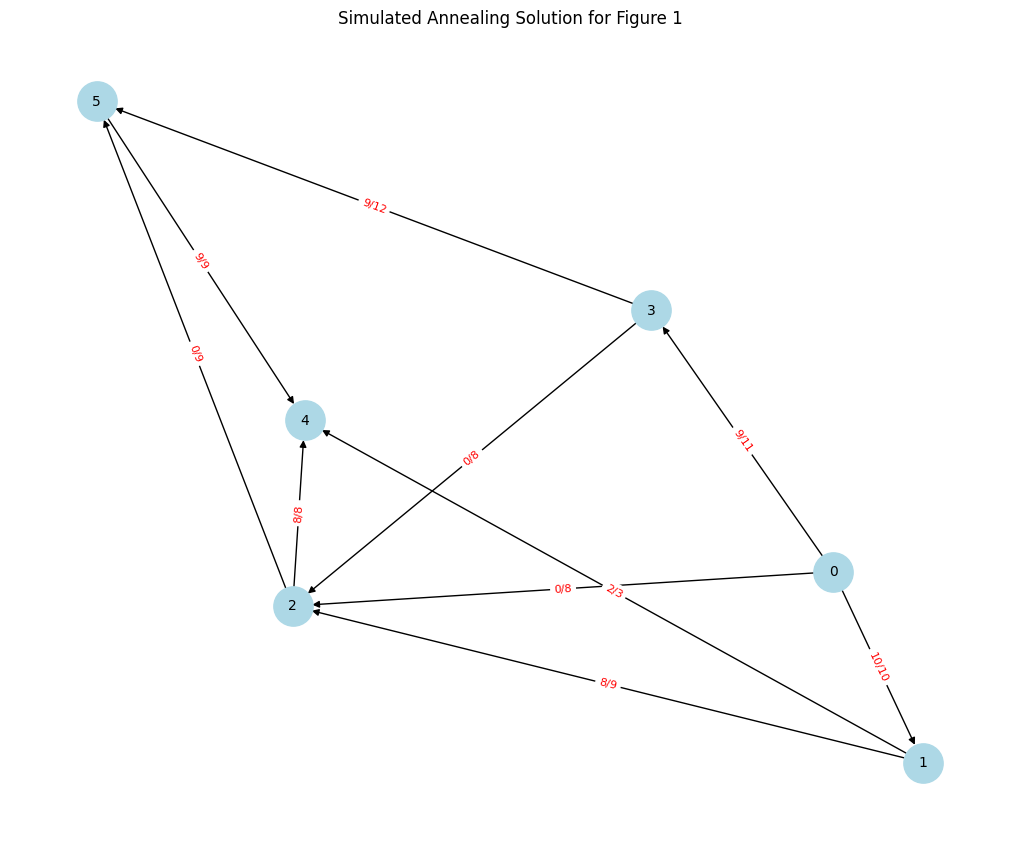


=== R2: Testing with Random Graph (30 nodes) ===
Graph has 30 nodes and 82 edges
Starting SA: T0=100, alpha=0.005
Initial flow: 0
Found 1 paths
Iteration 1000: T=0.67, Current=2, Best=2
Final flow: 2 (Best achieved: 2)

=== R2 Results ===
SA Flow (tf): 2
Edmonds-Karp Flow (tf_net): 2
Ratio (SA/EK): 1.000
SA achieved 100.0% of optimal flow

=== R3: Multiple Runs with Different Temperatures (30 graphs) ===

--- Processing graph 1/30 ---
Running with T=100...
Starting SA: T0=100, alpha=0.01
Initial flow: 0
Found 21467 paths
Final flow: 4 (Best achieved: 4)
Running with T=1000...
Starting SA: T0=1000, alpha=0.01
Initial flow: 0
Found 21467 paths
Iteration 1000: T=0.04, Current=4, Best=4
Final flow: 4 (Best achieved: 4)
Progress: 1/30 | Elapsed: 2.1s | Estimated remaining: 59.8s

--- Processing graph 2/30 ---
Running with T=100...
Starting SA: T0=100, alpha=0.01
Initial flow: 0
Found 15551 paths
Final flow: 1 (Best achieved: 1)
Running with T=1000...
Starting SA: T0=1000, alpha=0.01
Initia

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import math
import numpy as np
from networkx.algorithms.flow import edmonds_karp
import time

class NetworkFlowSA:
    def __init__(self, graph):
        self.graph = graph
        self.flow_state = {}
        self.initialize_flows()

    def initialize_flows(self):
        """Initialize all flows to 0"""
        for u, v in self.graph.edges():
            self.flow_state[(u, v)] = 0

    def heuristic_function(self, sink_node):
        """Calculate total flow into sink node"""
        total_flow = 0
        for u, v in self.graph.edges():
            if v == sink_node:
                total_flow += self.flow_state.get((u, v), 0)
        return total_flow

    def successor_function(self, source, sink):
        """Generate all simple paths from source to sink"""
        try:
            paths = list(nx.all_simple_paths(self.graph, source=source, target=sink))
            return paths
        except:
            return []

    def get_edge_capacity(self, u, v):
        """Get capacity of an edge"""
        return self.graph[u][v].get('capacity', 0)

    def calculate_flow_value(self, path):
        """Calculate maximum possible flow for a path"""
        min_capacity = float('inf')
        for i in range(len(path) - 1):
            u, v = path[i], path[i+1]
            capacity = self.get_edge_capacity(u, v)
            current_flow = self.flow_state.get((u, v), 0)
            residual = capacity - current_flow
            if residual < min_capacity:
                min_capacity = residual
        return max(0, min_capacity)

    def apply_flow_to_path(self, path, flow_value):
        """Apply flow to a path"""
        for i in range(len(path) - 1):
            u, v = path[i], path[i+1]
            self.flow_state[(u, v)] = self.flow_state.get((u, v), 0) + flow_value
            # Ensure flow doesn't exceed capacity
            capacity = self.get_edge_capacity(u, v)
            if self.flow_state[(u, v)] > capacity:
                self.flow_state[(u, v)] = capacity

    def simulated_annealing_driver(self, source, sink, initial_temperature=100, alpha=0.01, max_iterations=3000):
        """Main simulated annealing algorithm with improved parameters"""
        current_flow = self.heuristic_function(sink)
        paths = self.successor_function(source, sink)

        if not paths:
            print("No paths found from source to sink")
            return current_flow

        T = initial_temperature
        iteration = 0
        best_flow = current_flow

        print(f"Starting SA: T0={T}, alpha={alpha}")
        print(f"Initial flow: {current_flow}")
        print(f"Found {len(paths)} paths")

        while T > 0.01 and iteration < max_iterations:
            iteration += 1

            # Randomly select a path
            selected_path = random.choice(paths)

            # Calculate possible flow for this path
            possible_flow = self.calculate_flow_value(selected_path)

            if possible_flow > 0:
                # Create backup of current state
                backup_flow_state = self.flow_state.copy()
                backup_flow = current_flow

                # Apply the flow
                self.apply_flow_to_path(selected_path, possible_flow)
                new_flow = self.heuristic_function(sink)
                delta_flow = new_flow - current_flow

                # Acceptance criteria
                if delta_flow > 0:
                    # Always accept improvements
                    current_flow = new_flow
                    if current_flow > best_flow:
                        best_flow = current_flow
                else:
                    probability = math.exp(delta_flow / T) if T > 0 else 0
                    if random.random() < probability:
                        # Accept worse solution
                        current_flow = new_flow
                    else:
                        # Revert changes
                        self.flow_state = backup_flow_state
                        current_flow = backup_flow

            # Cool temperature
            T *= (1 - alpha)

            if iteration % 1000 == 0:
                print(f"Iteration {iteration}: T={T:.2f}, Current={current_flow}, Best={best_flow}")

        # Use best flow found during the process
        final_flow = best_flow
        print(f"Final flow: {final_flow} (Best achieved: {best_flow})")
        return final_flow

    def visualize_flow(self, title="Network Flow"):
        """Visualize the network with flow and capacity labels"""
        edge_labels = {}
        for u, v in self.graph.edges():
            flow = self.flow_state.get((u, v), 0)
            capacity = self.get_edge_capacity(u, v)
            edge_labels[(u, v)] = f"{flow}/{capacity}"

        pos = nx.spring_layout(self.graph)
        plt.figure(figsize=(10, 8))
        nx.draw(self.graph, pos, with_labels=True, node_color='lightblue',
                node_size=800, font_size=10, arrows=True)
        nx.draw_networkx_edge_labels(self.graph, pos, edge_labels=edge_labels,
                                   font_color='red', font_size=8)
        plt.title(title)
        plt.show()

# R1: Test with hardcoded graph from Figure 1
def requirement_1():
    print("=" * 70)
    print("=== R1: Testing with Figure 1 Graph ===")
    print("=" * 70)

    # Create the graph from Figure 1 (note: sink is node 4, which is E)
    G = nx.DiGraph()
    edges = [
        (0, 1, {'capacity': 10}),
        (0, 2, {'capacity': 8}),
        (0, 3, {'capacity': 11}),
        (1, 2, {'capacity': 9}),
        (1, 4, {'capacity': 3}),  # E is node 4
        (2, 4, {'capacity': 8}),  # E is node 4
        (2, 5, {'capacity': 9}),
        (3, 2, {'capacity': 8}),
        (3, 5, {'capacity': 12}),
        (5, 4, {'capacity': 9})   # E is node 4
    ]
    G.add_edges_from(edges)

    # Show all paths from source to sink
    print("Paths from source to sink:")
    for path in nx.all_simple_paths(G, source=0, target=4):
        print(path)

    # Run Simulated Annealing
    sa_solver = NetworkFlowSA(G)
    sa_flow = sa_solver.simulated_annealing_driver(source=0, sink=4,
                                                 initial_temperature=100,
                                                 alpha=0.01,
                                                 max_iterations=3000)

    # Compare with Edmonds-Karp
    R = edmonds_karp(G, 0, 4)
    ek_flow = nx.maximum_flow_value(R, 0, 4)

    print(f"\n=== R1 Results ===")
    print(f"SA Flow: {sa_flow}")
    print(f"Edmonds-Karp Flow: {ek_flow}")
    print(f"Difference: {abs(sa_flow - ek_flow)}")
    print(f"SA achieved {sa_flow/ek_flow*100:.1f}% of optimal flow")

    # Visualize results
    sa_solver.visualize_flow("Simulated Annealing Solution for Figure 1")

    return sa_flow, ek_flow

# R2: Test with random graph (30 nodes)
def requirement_2():
    print("\n" + "=" * 70)
    print("=== R2: Testing with Random Graph (30 nodes) ===")
    print("=" * 70)

    # Create random graph with 30 nodes and connectivity 0.1
    N = 30
    G = nx.gnp_random_graph(N, 0.1, directed=True)

    # Ensure the graph is connected by adding edges if needed
    if not nx.is_weakly_connected(G):
        components = list(nx.weakly_connected_components(G))
        for i in range(len(components) - 1):
            node1 = random.choice(list(components[i]))
            node2 = random.choice(list(components[i + 1]))
            G.add_edge(node1, node2)

    # Assign random capacities (1-10)
    for u, v in G.edges():
        G[u][v]['capacity'] = random.randint(1, 10)

    print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

    # Run Simulated Annealing with improved parameters
    sa_solver = NetworkFlowSA(G)
    sa_flow = sa_solver.simulated_annealing_driver(source=0, sink=29,
                                                 initial_temperature=100,
                                                 alpha=0.005,  # Slower cooling
                                                 max_iterations=4000)  # More iterations

    # Compare with Edmonds-Karp
    try:
        R = edmonds_karp(G, 0, 29)
        ek_flow = nx.maximum_flow_value(R, 0, 29)
    except:
        ek_flow = 0
        print("Edmonds-Karp algorithm failed")

    print(f"\n=== R2 Results ===")
    print(f"SA Flow (tf): {sa_flow}")
    print(f"Edmonds-Karp Flow (tf_net): {ek_flow}")

    if ek_flow > 0:
        print(f"Ratio (SA/EK): {sa_flow/ek_flow:.3f}")
        print(f"SA achieved {sa_flow/ek_flow*100:.1f}% of optimal flow")

    return sa_flow, ek_flow

# R3: Multiple runs with different temperatures (FULL 30 GRAPHS)
def requirement_3():
    print("\n" + "=" * 70)
    print("=== R3: Multiple Runs with Different Temperatures (30 graphs) ===")
    print("=" * 70)

    results_100 = []
    results_1000 = []
    num_graphs = 30  # CHANGED TO 30 AS REQUIRED

    start_time = time.time()

    for i in range(num_graphs):
        print(f"\n--- Processing graph {i+1}/{num_graphs} ---")

        # Create random graph
        N = 30
        G = nx.gnp_random_graph(N, 0.1, directed=True)

        # Ensure connectivity
        if not nx.is_weakly_connected(G):
            components = list(nx.weakly_connected_components(G))
            for j in range(len(components) - 1):
                node1 = random.choice(list(components[j]))
                node2 = random.choice(list(components[j + 1]))
                G.add_edge(node1, node2)

        # Assign random capacities
        for u, v in G.edges():
            G[u][v]['capacity'] = random.randint(1, 10)

        # Run with T=100
        print("Running with T=100...")
        sa_solver = NetworkFlowSA(G)
        flow_100 = sa_solver.simulated_annealing_driver(source=0, sink=29,
                                                      initial_temperature=100,
                                                      alpha=0.01,
                                                      max_iterations=2000)
        results_100.append(flow_100)

        # Run with T=1000 (reset and use same graph)
        print("Running with T=1000...")
        sa_solver.initialize_flows()
        flow_1000 = sa_solver.simulated_annealing_driver(source=0, sink=29,
                                                       initial_temperature=1000,
                                                       alpha=0.01,
                                                       max_iterations=2000)
        results_1000.append(flow_1000)

        # Progress update
        elapsed = time.time() - start_time
        avg_time_per_graph = elapsed / (i + 1)
        remaining_graphs = num_graphs - (i + 1)
        estimated_remaining = avg_time_per_graph * remaining_graphs
        print(f"Progress: {i+1}/{num_graphs} | Elapsed: {elapsed:.1f}s | Estimated remaining: {estimated_remaining:.1f}s")

    # Calculate averages
    avg_100 = np.mean(results_100)
    avg_1000 = np.mean(results_1000)

    print(f"\n" + "=" * 50)
    print("=== R3 Final Results ===")
    print("=" * 50)

    print(f"\nResults for T=100:")
    print(f"  Average flow (tf_net_avg(100)): {avg_100:.3f}")
    print(f"  Std deviation: {np.std(results_100):.3f}")
    print(f"  Min: {np.min(results_100)}, Max: {np.max(results_100)}")

    print(f"\nResults for T=1000:")
    print(f"  Average flow (tf_net_avg(1000)): {avg_1000:.3f}")
    print(f"  Std deviation: {np.std(results_1000):.3f}")
    print(f"  Min: {np.min(results_1000)}, Max: {np.max(results_1000)}")

    print(f"\nDifference (T1000 - T100): {avg_1000 - avg_100:.3f}")
    print(f"Percentage improvement: {(avg_1000 - avg_100)/avg_100*100:.1f}%")

    # Statistical analysis
    try:
        from scipy import stats
        t_stat, p_value = stats.ttest_rel(results_100, results_1000)  # Using paired t-test

        print(f"\n=== Statistical Analysis ===")
        print(f"T-test p-value: {p_value:.4f}")

        if p_value < 0.05:
            print("✓ Significant difference detected (p < 0.05)")
            print("  - Higher temperature allows better exploration of solution space")
            print("  - More uphill moves accepted, escaping local optima")
        else:
            print("✗ No significant difference detected (p >= 0.05)")
            print("  - Temperature may not be the limiting factor")
            print("  - Solution space might be relatively smooth")
            print("  - Other parameters (alpha, iterations) might need tuning")

    except ImportError:
        print("\nNote: scipy not available for statistical test")

    return avg_100, avg_1000, results_100, results_1000

# Main execution
if __name__ == "__main__":
    total_start_time = time.time()

    # R1: Test with Figure 1 graph
    sa_flow_r1, ek_flow_r1 = requirement_1()

    # R2: Test with random 30-node graph
    sa_flow_r2, ek_flow_r2 = requirement_2()

    # R3: Multiple runs with different temperatures (FULL 30 GRAPHS)
    avg_100, avg_1000, results_100, results_1000 = requirement_3()

    total_end_time = time.time()
    total_duration = total_end_time - total_start_time

    print(f"\n" + "=" * 70)
    print("=== PROJECT 2 PART B - COMPLETED ===")
    print("=" * 70)
    print(f"Total execution time: {total_duration:.2f} seconds ({total_duration/60:.1f} minutes)")
    print(f"R1: SA Flow = {sa_flow_r1}, EK Flow = {ek_flow_r1}")
    print(f"R2: SA Flow = {sa_flow_r2}, EK Flow = {ek_flow_r2}")
    print(f"R3: Avg T100 = {avg_100:.2f}, Avg T1000 = {avg_1000:.2f}")
    print("=" * 70)